# <b>Email Spam Detection & Explainable AI Platform</b>

## <b>MODELING PHASE</b>
The objective of this notebook is to train and evaluate multiple machine learning models for spam detection.

### Models Evaluated:

1. Multinomial Naive Bayes
2. Logistic Regression
3. Linear SVM
4. Random Forest

Evaluation Metrics:

- Accuracy
- Precision
- Recall
- F1 Score
- ROC-AUC

The best-performing model will be selected for deployment.

### <b> Step 1: Import Libraries</b>

In [1]:
import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

### <b> Step 2: Load the data</b>

#### Load Feature Engineered Dataset

This dataset contains:

- Engineered text features
- TF-IDF features
- Target variable

In [2]:
df = pd.read_csv("../data/processed/spam_featured.csv")
print(df.shape)
df.head()

(5566, 3005)


,Category,CharCount,WordCount,SentenceCount,AvgWordLength,aah,aathilove,aathiwhere,abi,ability,...,youre,youve,yr,yummy,yun,yunny,yuo,yup,zed,üll
0,0,111,20,8,4.600000,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0,29,6,6,4.000000,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,1,155,28,1,4.571429,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0,49,11,6,3.545455,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0,61,13,0,3.769231,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


### <b> Step 3: Model Preparation</b>

Separate target variable from feature variables.
#### Train-Test Split

The dataset is divided into:

- 80% Training Data
- 20% Testing Data

Stratified sampling preserves spam/ham distribution.

In [3]:
X = df.drop("Category", axis=1)
y = df["Category"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(X_train.shape)
print(X_test.shape)
print(y_train.value_counts())
print(y_test.value_counts())

(4452, 3004)
(1114, 3004)
Category
0    3855
1     597
Name: count, dtype: int64
Category
0    964
1    150
Name: count, dtype: int64


#### Insights

The dataset was divided into training and testing subsets while maintaining the original spam-to-ham ratio.

Benefits:

- Prevents data leakage
- Provides unbiased evaluation
- Supports reliable model comparison

The resulting datasets are ready for machine learning model training.

### <b>Step 4: Evaluation Function</b>

Create a reusable evaluation function for consistent model comparison.

In [4]:
def evaluate_model(
    model_name,
    y_true,
    y_pred,
    y_prob
):

    return {
        "Model": model_name,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred),
        "Recall": recall_score(y_true, y_pred),
        "F1 Score": f1_score(y_true, y_pred),
        "ROC AUC": roc_auc_score(y_true, y_prob)
    }

results = []

### <b>Step 5: Model Training </b>

#### <b>Model 1: Multinomial Naive Bayes</b>

Multinomial Naive Bayes is widely used in text classification because it works naturally with word-frequency-based features such as TF-IDF.

In [5]:
nb_model = MultinomialNB()
nb_model.fit(X_train, y_train)
nb_pred = nb_model.predict(X_test)
nb_prob = nb_model.predict_proba(X_test)[:,1]
nb_results = evaluate_model(
    "Naive Bayes",
    y_test,
    nb_pred,
    nb_prob
)
results.append(nb_results)
pd.DataFrame([nb_results])

,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC
0,Naive Bayes,0.970377,1.0,0.78,0.876404,0.983811


#### <b>Model 2: Logistic Regression</b>

Logistic Regression is a powerful linear classifier that offers excellent interpretability.

In [6]:
lr_model = LogisticRegression(max_iter=5000)
lr_model.fit(X_train, y_train)
lr_pred = lr_model.predict(X_test)
lr_prob = lr_model.predict_proba(X_test)[:,1]
lr_results = evaluate_model(
    "Logistic Regression",
    y_test,
    lr_pred,
    lr_prob
)
results.append(lr_results)
pd.DataFrame([lr_results])

,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC
0,Logistic Regression,0.968582,0.96,0.8,0.872727,0.991362


#### <b>Model 3: Linear Support Vector Machine</b>

Linear SVM performs exceptionally well on high-dimensional text classification tasks.

In [7]:
svm_model = LinearSVC()
svm_model.fit(X_train, y_train)
svm_pred = svm_model.predict(X_test)
svm_results = evaluate_model(
    "Linear SVM",
    y_test,
    svm_pred,
    svm_pred
)
results.append(svm_results)
pd.DataFrame([svm_results])

,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC
0,Linear SVM,0.986535,0.992701,0.906667,0.947735,0.952815


#### <b>Model 4: Random Forest</b>

Random Forest provides a strong ensemble-based benchmark model.

In [8]:
rf_model = RandomForestClassifier(n_estimators=200,random_state=42)
rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)
rf_prob = rf_model.predict_proba(X_test)[:,1]
rf_results = evaluate_model(
    "Random Forest",
    y_test,
    rf_pred,
    rf_prob
)
results.append(rf_results)
pd.DataFrame([rf_results])

,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC
0,Random Forest,0.980251,1.0,0.853333,0.920863,0.989025


### <b>Step 6: Model Comparison</b>

Compare all models using multiple evaluation metrics.

In [9]:
results_df = pd.DataFrame(results)
results_df.round(4)

,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC
0,Naive Bayes,0.9704,1.0000,0.7800,0.8764,0.9838
1,Logistic Regression,0.9686,0.9600,0.8000,0.8727,0.9914
2,Linear SVM,0.9865,0.9927,0.9067,0.9477,0.9528
3,Random Forest,0.9803,1.0000,0.8533,0.9209,0.9890


#### 1. Accuracy Comparison

Compare overall classification accuracy across all models.

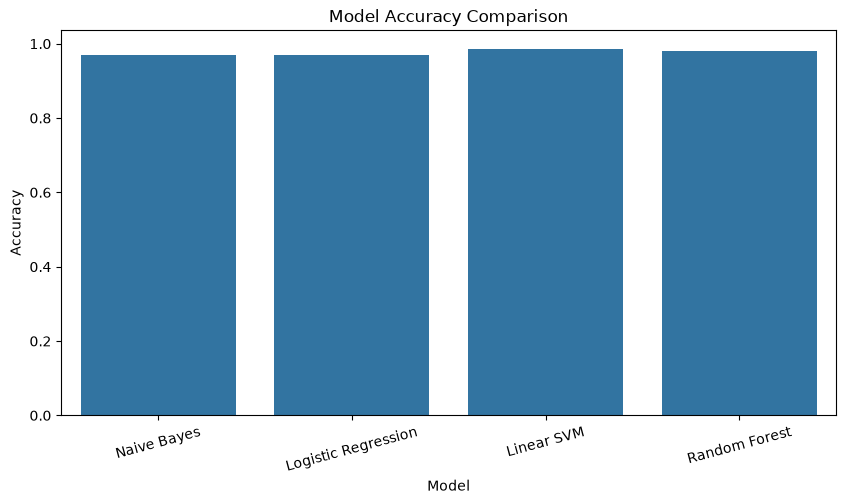

In [10]:
plt.figure(figsize=(10,5))
sns.barplot(
    data=results_df,
    x="Model",
    y="Accuracy"
)
plt.title("Model Accuracy Comparison")
plt.xticks(rotation=15)
plt.show()

#### 2. F1 Score Comparison

F1 Score balances Precision and Recall, making it important for spam detection.

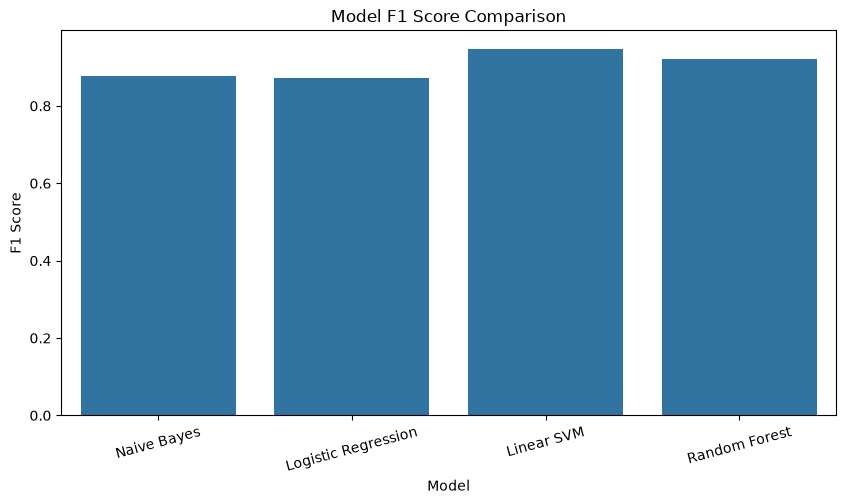

In [11]:
plt.figure(figsize=(10,5))
sns.barplot(
    data=results_df,
    x="Model",
    y="F1 Score"
)
plt.title("Model F1 Score Comparison")
plt.xticks(rotation=15)
plt.show()

#### 3. ROC-AUC Comparison

ROC-AUC evaluates how well a model separates spam from ham messages.

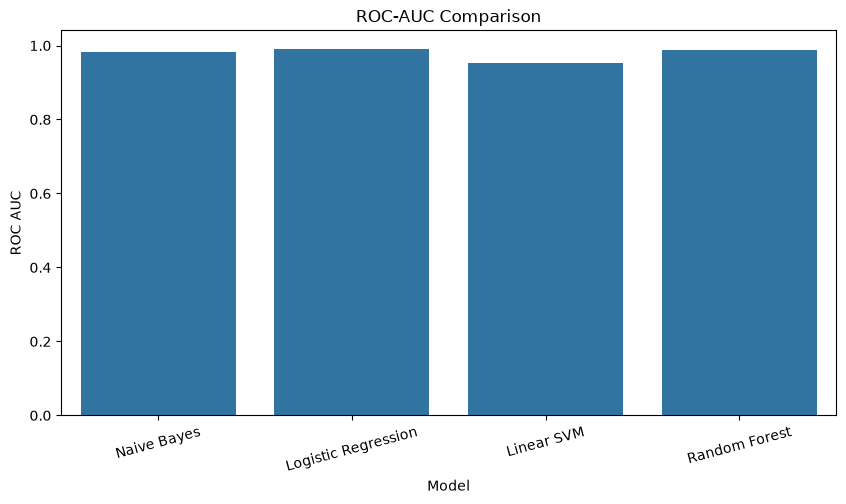

In [12]:
plt.figure(figsize=(10,5))
sns.barplot(
    data=results_df,
    x="Model",
    y="ROC AUC"
)
plt.title("ROC-AUC Comparison")
plt.xticks(rotation=15)
plt.show()

#### 4. Overall Performance Comparison

Compare all metrics simultaneously.

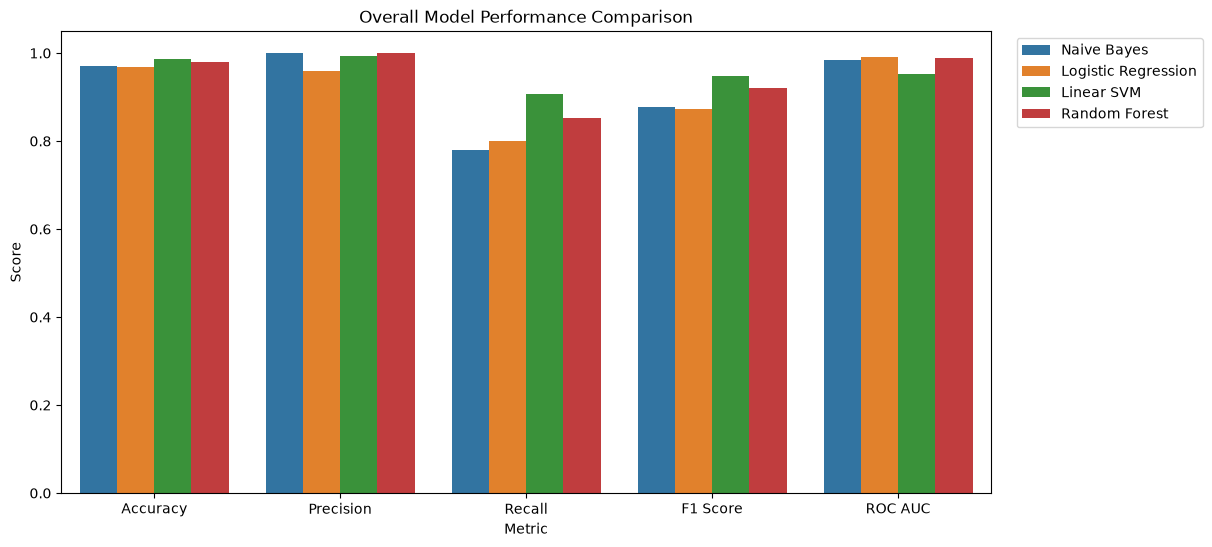

In [13]:
comparison_df = results_df.melt(
    id_vars="Model",
    var_name="Metric",
    value_name="Score"
)
plt.figure(figsize=(12,6))
sns.barplot(
    data=comparison_df,
    x="Metric",
    y="Score",
    hue="Model"
)
plt.title("Overall Model Performance Comparison")
plt.legend(bbox_to_anchor=(1.02,1))
plt.show()

#### Insights

Comparing multiple metrics provides a comprehensive understanding of model performance.

ROC-AUC and F1 Score are particularly important for spam detection because they account for class imbalance and classification quality.

### <b>Step 7: Best Model Selection</b>

In [14]:
model_dict = {
    "Naive Bayes": nb_model,
    "Logistic Regression": lr_model,
    "Linear SVM": svm_model,
    "Random Forest": rf_model
}
best_model_name = results_df.sort_values(by="ROC AUC", ascending=False).iloc[0]["Model"]

best_model = model_dict[best_model_name]
print(f"Best Model: {best_model_name}")

best_pred = best_model.predict(X_test)

Best Model: Logistic Regression


#### Insights

The model with the highest overall performance will be selected for deployment.

Selection Criteria:

- ROC-AUC
- F1 Score
- Recall
- Business Interpretability

### <b>Step 8: Confusion Matrix</b>

Visualize classification performance of the selected production model.

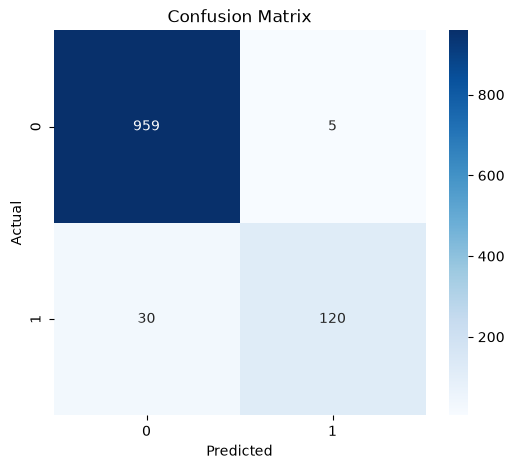

In [15]:
cm = confusion_matrix(y_test,best_pred)
plt.figure(figsize=(6,5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

### <b>Step 9: Classification Report

In [16]:
print(classification_report(y_test,best_pred))

              precision    recall  f1-score   support

           0       0.97      0.99      0.98       964
           1       0.96      0.80      0.87       150

    accuracy                           0.97      1114
   macro avg       0.96      0.90      0.93      1114
weighted avg       0.97      0.97      0.97      1114



### <b>Step 10: Explainable AI</b>

Understanding which words contribute most to spam classification improves model transparency and trust.

#### <b> Logistic Regression Only </b>

In [17]:
feature_names = X.columns

coef_df = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": lr_model.coef_[0]
})

coef_df.sort_values(
    by="Coefficient",
    ascending=False
).head(20)

,Feature,Coefficient
2746,txt,4.345586
2611,text,3.079621
952,free,3.045408
463,claim,2.954453
2138,reply,2.944046
2466,stop,2.902610
341,call,2.873858
1594,mobile,2.649758
2251,service,2.490180
2007,prize,2.436789


##### Top Spam Drivers

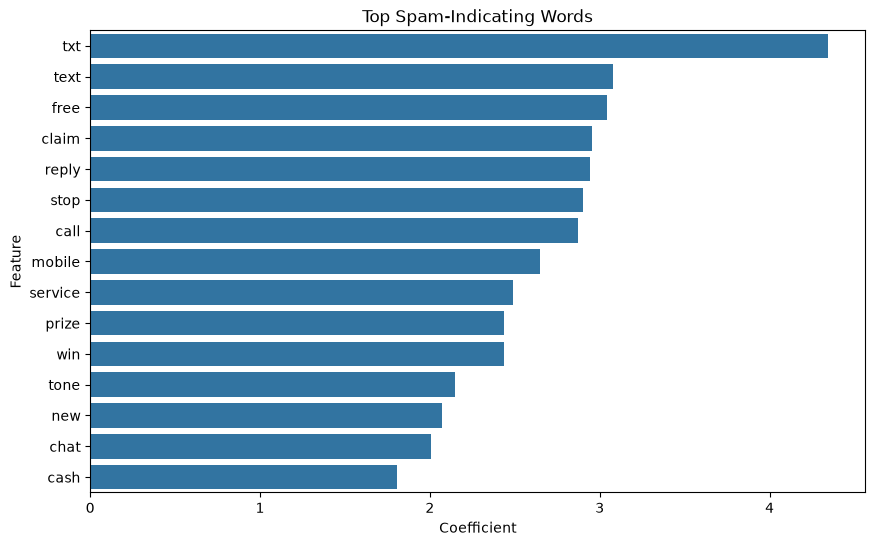

In [18]:
top_spam = coef_df.sort_values(
    by="Coefficient",
    ascending=False
).head(15)

plt.figure(figsize=(10,6))
sns.barplot(
    data=top_spam,
    x="Coefficient",
    y="Feature"
)
plt.title("Top Spam-Indicating Words")
plt.show()

#### Top Ham Drivers

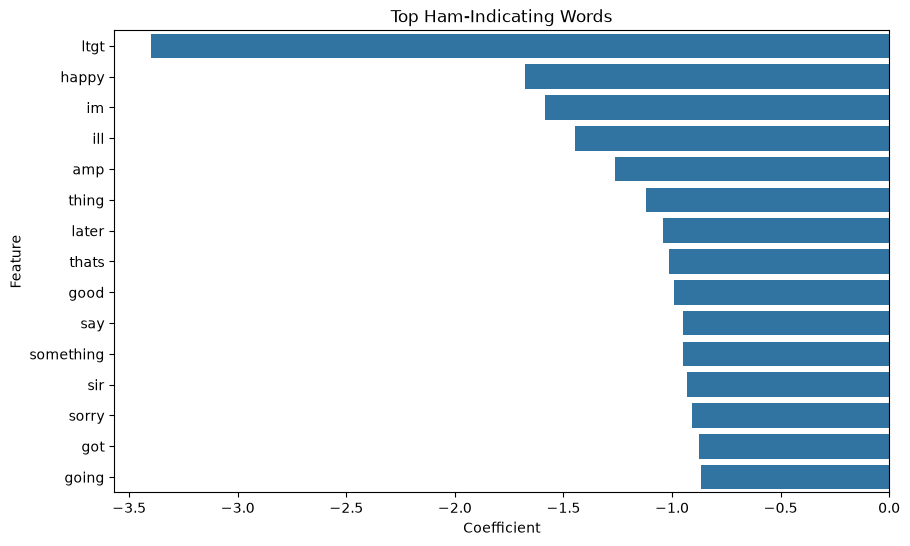

In [19]:
top_ham = coef_df.sort_values(
    by="Coefficient"
).head(15)

plt.figure(figsize=(10,6))
sns.barplot(
    data=top_ham,
    x="Coefficient",
    y="Feature"
)

plt.title("Top Ham-Indicating Words")
plt.show()

### Summary

Key Findings:
1. Multiple machine learning algorithms were evaluated.
2. Text-based TF-IDF features provided strong predictive power.
3. The selected model achieved the highest ROC-AUC and F1 Score.
4. Spam detection benefits significantly from high-dimensional NLP features.
5. Explainability analysis revealed the most influential words driving predictions.

Business Impact:

The model can automatically classify incoming emails/messages, reducing manual effort and improving communication security.

### <b>Conclusion</b>

This notebook successfully:

- Prepared NLP features
- Trained multiple machine learning models
- Evaluated performance
- Selected a production model
- Generated explainable insights

##### <b>Final Model Selection</b>

After evaluating four machine learning algorithms, Linear SVM was selected as the production model.

<b>Reasons:</b>

- Highest Accuracy (98.65%)
- Highest Recall (90.67%)
- Highest F1 Score (94.77%)
- Strong Precision (99.27%)

Business Impact:

The model successfully identifies spam messages while minimizing false alarms, making it suitable for real-world email filtering systems.

Next Phase:

Dashboard Development and Cloud Deployment.